# Libraries and Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Loading Datasets

In [13]:
Path = ("/Users/mehreenwerth/Desktop/citibike-weather-2022")

In [12]:
trips = pd.read_csv("data_processed/daily_citibike_2022.csv")
weather = pd.read_csv("data_processed/weather_lga_2022.csv")

In [23]:
trips["date"] = pd.to_datetime(trips["date"])
weather["date"] = pd.to_datetime(weather["date"])

In [24]:
weather_merged = weather.merge(trips, on="date", how="left")

weather_merged["trip_count"] = weather_merged["trip_count"].fillna(0)

In [16]:
trips = trips[(trips["date"] >= "2022-01-01") & (trips["date"] < "2023-01-01")]
weather = weather[(weather["date"] >= "2022-01-01") & (weather["date"] < "2023-01-01")]

trips.head(), weather.head()

(         date  trip_count  avg_trip_minutes  member_trips  casual_trips
 0  2022-01-01       20428         32.924663         14040          6388
 1  2022-01-02       43009         39.528753         31016         11993
 2  2022-01-03       33189         42.556438         28717          4472
 3  2022-01-04       36842         49.943315         31669          5173
 4  2022-01-05       34230         35.114449         29313          4917,
          date   ADPT     ASLP     ASTP   AWBT  AWND  PRCP  RHAV  RHMN  RHMX  \
 0  2022-01-01  100.0  10078.0  10078.0  106.0   2.8  19.3  89.0  83.0  93.0   
 1  2022-01-02   67.0  10051.0  10024.0   83.0   4.3   1.0  80.0  63.0  93.0   
 2  2022-01-03 -100.0  10196.0  10169.0  -39.0   6.4   0.0  49.0  38.0  62.0   
 3  2022-01-04 -117.0  10281.0  10268.0  -44.0   3.9   0.0  48.0  35.0  60.0   
 4  2022-01-05    6.0  10132.0  10139.0   33.0   3.4   6.1  76.0  52.0  86.0   
 
    ...   WDF5  WSF2  WSF5  WT01  WT02  WT03  WT04  WT06  WT08  WT09  
 0  ... 

# Checking Weather Format

In [18]:
weather.columns

Index(['date', 'ADPT', 'ASLP', 'ASTP', 'AWBT', 'AWND', 'PRCP', 'RHAV', 'RHMN',
       'RHMX', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WDF2', 'WDF5', 'WSF2',
       'WSF5', 'WT01', 'WT02', 'WT03', 'WT04', 'WT06', 'WT08', 'WT09'],
      dtype='object')

In [19]:
weather.head()

,date,ADPT,ASLP,ASTP,AWBT,AWND,PRCP,RHAV,RHMN,RHMX,...,WDF5,WSF2,WSF5,WT01,WT02,WT03,WT04,WT06,WT08,WT09
0,2022-01-01,100.0,10078.0,10078.0,106.0,2.8,19.3,89.0,83.0,93.0,...,200.0,6.3,7.6,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-02,67.0,10051.0,10024.0,83.0,4.3,1.0,80.0,63.0,93.0,...,310.0,12.5,14.8,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-03,-100.0,10196.0,10169.0,-39.0,6.4,0.0,49.0,38.0,62.0,...,350.0,12.5,15.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-04,-117.0,10281.0,10268.0,-44.0,3.9,0.0,48.0,35.0,60.0,...,350.0,8.9,12.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-05,6.0,10132.0,10139.0,33.0,3.4,6.1,76.0,52.0,86.0,...,200.0,6.7,10.7,1.0,NaN,NaN,NaN,NaN,1.0,NaN


# Temperature Plot

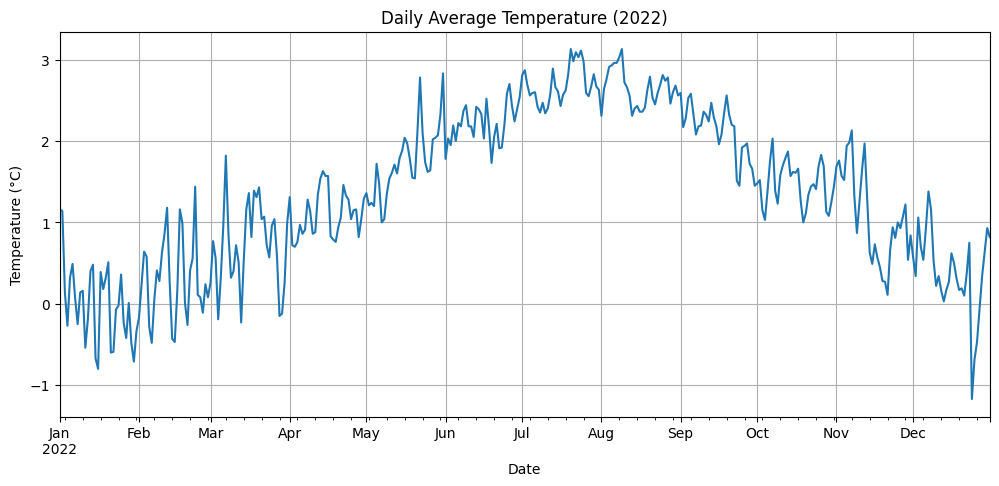

In [21]:
weather["date"] = pd.to_datetime(weather["date"])

weather["TAVG_C"] = weather["TAVG"] / 10

weather.set_index("date")["TAVG_C"].plot(
    kind="line",
    title="Daily Average Temperature (2022)",
    xlabel="Date",
    ylabel="Temperature (°C)",
)

plt.show()

# Dual Axis Plot - Left Axis = Trip Count, Right Axis = Temperature

In [27]:
weather_merged["TAVG_C"] = weather_merged["TAVG"] / 10

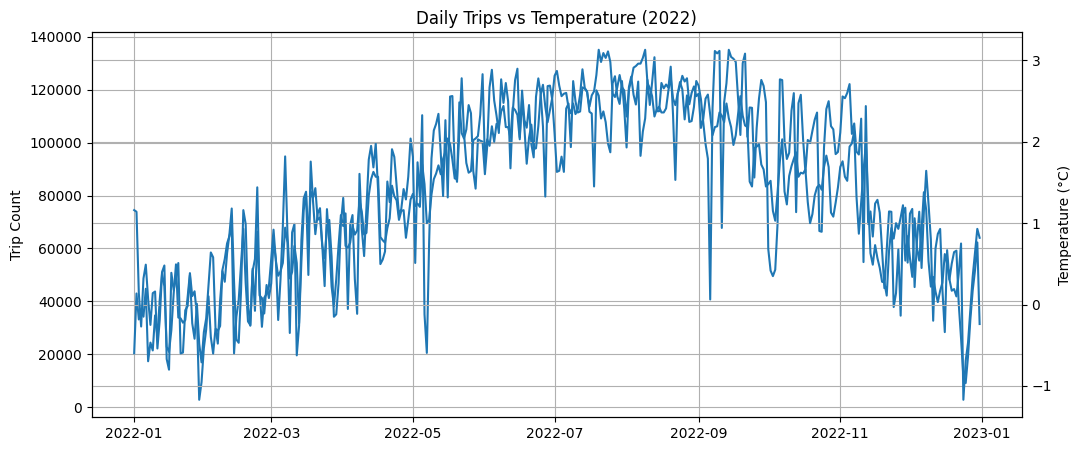

In [28]:
df = weather_merged.sort_values("date").set_index("date")

fig, ax1 = plt.subplots()

ax1.plot(df.index, df["trip_count"])
ax1.set_ylabel("Trip Count")

ax2 = ax1.twinx()
ax2.plot(df.index, df["TAVG_C"])
ax2.set_ylabel("Temperature (°C)")

plt.title("Daily Trips vs Temperature (2022)")
plt.show()

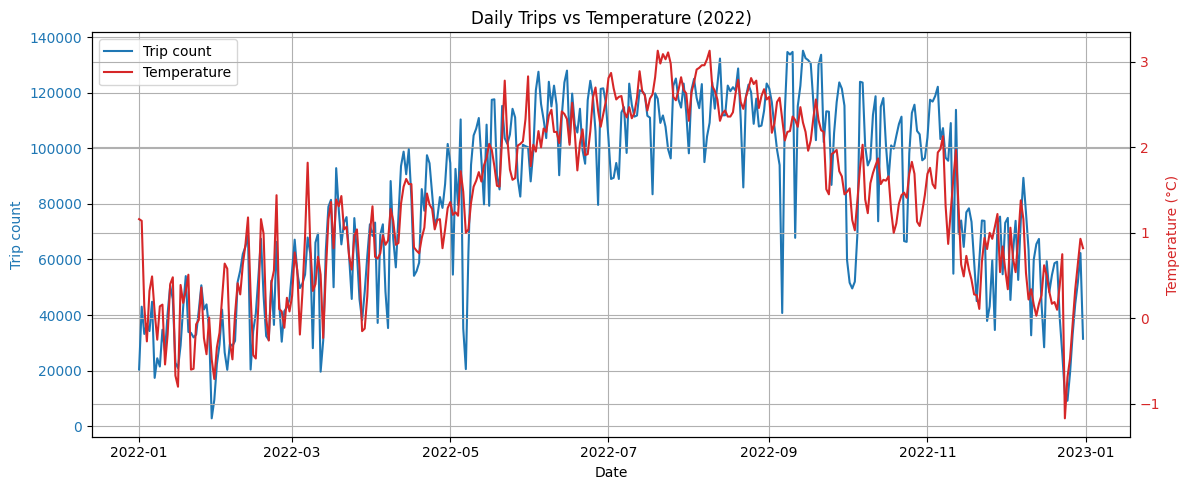

In [31]:
fig, ax1 = plt.subplots()

line1, = ax1.plot(
    df.index,
    df["trip_count"],
    color="tab:blue",
    label="Trip count"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Trip count", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()

line2, = ax2.plot(
    df.index,
    df["TAVG_C"],
    color="tab:red",
    label="Temperature"
)

ax2.set_ylabel("Temperature (°C)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Daily Trips vs Temperature (2022)")

ax1.legend(handles=[line1, line2], loc="upper left")

fig.tight_layout()
plt.show()

### I plotted temperature and Citi Bike trip counts as time series for 2022. The temperature plot used pandas .plot() (Matplotlib backend). For the combined plot, I used Matplotlib’s object-oriented interface: I created fig, ax1 with plt.subplots(), plotted trip counts on ax1, then used ax1.twinx() to add ax2 for temperature on a second y-axis. I customized axis labels, legend, and colors for readability.